# Task
Analyze feedback data from the `/content/Feedback Feedback Date Date.csv` file by loading it into a pandas DataFrame, exploring its structure and quality, identifying trends, detecting anomalies, visualizing these trends and anomalies, and summarizing insights into their potential causes or implications.

## Load Data

### Subtask:
Load the data from the provided CSV file `/content/Feedback Feedback Date Date.csv` into a pandas DataFrame.


**Reasoning**:
To load the data, I will first import the pandas library and then use its `read_csv` function to load the specified file into a DataFrame named `df`. Finally, I will display the first few rows to ensure the data is loaded correctly.



In [ ]:
# dataframe:
# uuid: A130FB87-5953-4F2D-8F6D-CE6D2E01998B
# output_variable:
# config_str:

import google.colabsqlviz.explore_dataframe as _vizcell
_vizcell.explore_dataframe(df_or_df_name='', uuid='A130FB87-5953-4F2D-8F6D-CE6D2E01998B')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Feedback Feedback Date Date.csv')
df.head()

,Feedback Feedback Date Date,Content Content Platform,Content Content Owner,Content Content Name,Feedback Csat,Feedback Csat Explanation,Feedback Csat Lab Quality,Feedback Csat Lecture Quality,Feedback Csat Open Feedback,Feedback Csat Materials,Feedback Csat Lab Lecture Balance,Content Content Code,Content Content Language
0,2023-05-09,Skills Boost (QL) - OnDemand,stripling,Introduction to Generative AI,5.0,"Fantastic intro video, very accessible and con...",4.0,5.0,Perfect intro. I can't wait for the next courses,NaN,3.0,G-GENAI-I,english
1,2023-05-10,Skills Boost (QL) - OnDemand,stripling,Introduction to Generative AI,5.0,NaN,NaN,NaN,NaN,NaN,NaN,G-GENAI-I,english
2,2023-05-10,Skills Boost (QL) - OnDemand,stripling,Introduction to Generative AI,5.0,NaN,NaN,5.0,NaN,NaN,3.0,G-GENAI-I,english
3,2023-05-10,Skills Boost (QL) - OnDemand,stripling,Introduction to Generative AI,2.0,Several answers in the assessment were misspel...,NaN,5.0,"The voice over was very robotic, perhaps compu...",NaN,NaN,G-GENAI-I,english
4,2023-05-10,Skills Boost (QL) - OnDemand,stripling,Introduction to Generative AI,5.0,Very informative as an introduction,NaN,NaN,NaN,NaN,NaN,G-GENAI-I,english


## Data Exploration

### Subtask:
Examine the dataset to understand its structure, identify relevant columns for trend analysis, and check for any initial data quality issues. This will involve checking data types, summary statistics, and potential missing values.


**Reasoning**:
To understand the dataset's structure and quality, I will first display the DataFrame's info to check data types and non-null counts, then generate descriptive statistics for numerical columns, count unique values per column, and finally calculate the percentage of missing values for each column.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nNumber of Unique Values per Column:")
print(df.nunique())

print("\nPercentage of Missing Values per Column:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage.sort_values(ascending=False))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Feedback Feedback Date Date        30000 non-null  object 
 1   Content Content Platform           30000 non-null  object 
 2   Content Content Owner              29997 non-null  object 
 3   Content Content Name               30000 non-null  object 
 4   Feedback Csat                      29191 non-null  float64
 5   Feedback Csat Explanation          13588 non-null  object 
 6   Feedback Csat Lab Quality          22597 non-null  float64
 7   Feedback Csat Lecture Quality      25181 non-null  float64
 8   Feedback Csat Open Feedback        9148 non-null   object 
 9   Feedback Csat Materials            0 non-null      float64
 10  Feedback Csat Lab Lecture Balance  23904 non-null  float64
 11  Content Content Code               300

## Identify Trends

### Subtask:
Analyze the data to identify underlying trends, focusing on CSAT scores over time and across different content categories.


**Reasoning**:
To prepare the data for trend analysis, I will first convert the date column to datetime objects, then remove the 'Feedback Csat Materials' column which is entirely null, and finally fill the missing values in relevant CSAT score columns with their respective median values to maintain data integrity.



In [ ]:
df['Feedback Feedback Date Date'] = pd.to_datetime(df['Feedback Feedback Date Date'])

df = df.drop(columns=['Feedback Csat Materials'])

csat_cols = ['Feedback Csat', 'Feedback Csat Lab Quality', 'Feedback Csat Lecture Quality', 'Feedback Csat Lab Lecture Balance']
for col in csat_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("Data cleaning completed. DataFrame info after cleaning:")
df.info()

Data cleaning completed. DataFrame info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Feedback Feedback Date Date        30000 non-null  datetime64[ns]
 1   Content Content Platform           30000 non-null  object        
 2   Content Content Owner              29997 non-null  object        
 3   Content Content Name               30000 non-null  object        
 4   Feedback Csat                      30000 non-null  float64       
 5   Feedback Csat Explanation          13588 non-null  object        
 6   Feedback Csat Lab Quality          30000 non-null  float64       
 7   Feedback Csat Lecture Quality      30000 non-null  float64       
 8   Feedback Csat Open Feedback        9148 non-null   object        
 9   Feedback Csat Lab Lecture Balance  30000 non-null

**Reasoning**:
To identify trends, I will group the DataFrame by date, content platform, content owner, and content language, calculating the mean of 'Feedback Csat' for each group, and then display the head of the resulting aggregated dataframes.



In [ ]:
daily_avg_csat = df.groupby('Feedback Feedback Date Date')['Feedback Csat'].mean()
platform_avg_csat = df.groupby('Content Content Platform')['Feedback Csat'].mean()
owner_avg_csat = df.groupby('Content Content Owner')['Feedback Csat'].mean()
language_avg_csat = df.groupby('Content Content Language')['Feedback Csat'].mean()

print("\nDaily Average CSAT (head):")
print(daily_avg_csat.head())

print("\nAverage CSAT by Content Platform:")
print(platform_avg_csat)

print("\nAverage CSAT by Content Owner:")
print(owner_avg_csat)

print("\nAverage CSAT by Content Language:")
print(language_avg_csat)


Daily Average CSAT (head):
Feedback Feedback Date Date
2023-05-09    5.000000
2023-05-10    4.461538
2023-05-11    4.526316
2023-05-12    3.833333
2023-05-13    4.923077
Name: Feedback Csat, dtype: float64

Average CSAT by Content Platform:
Content Content Platform
Coursera                        4.467532
Skills Boost (QL) - OnDemand    4.361595
Name: Feedback Csat, dtype: float64

Average CSAT by Content Owner:
Content Content Owner
stripling    4.366613
suprune      4.692308
Name: Feedback Csat, dtype: float64

Average CSAT by Content Language:
Content Content Language
bahasa                  5.000000
brazilian portuguese    4.666667
english                 4.366613
french                  4.750000
italian                 4.333333
japanese                5.000000
korean                  5.000000
spanish                 4.625000
traditional chinese     5.000000
Name: Feedback Csat, dtype: float64


**Reasoning**:
To visualize the identified trends, I will import `matplotlib.pyplot` and `seaborn` libraries, which are essential for creating informative and aesthetically pleasing plots.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries for visualization imported.")

Libraries for visualization imported.


**Reasoning**:
To visualize the daily average CSAT scores, I will create a line plot using `daily_avg_csat` to show the trend over time, adding a title and labels for clarity.



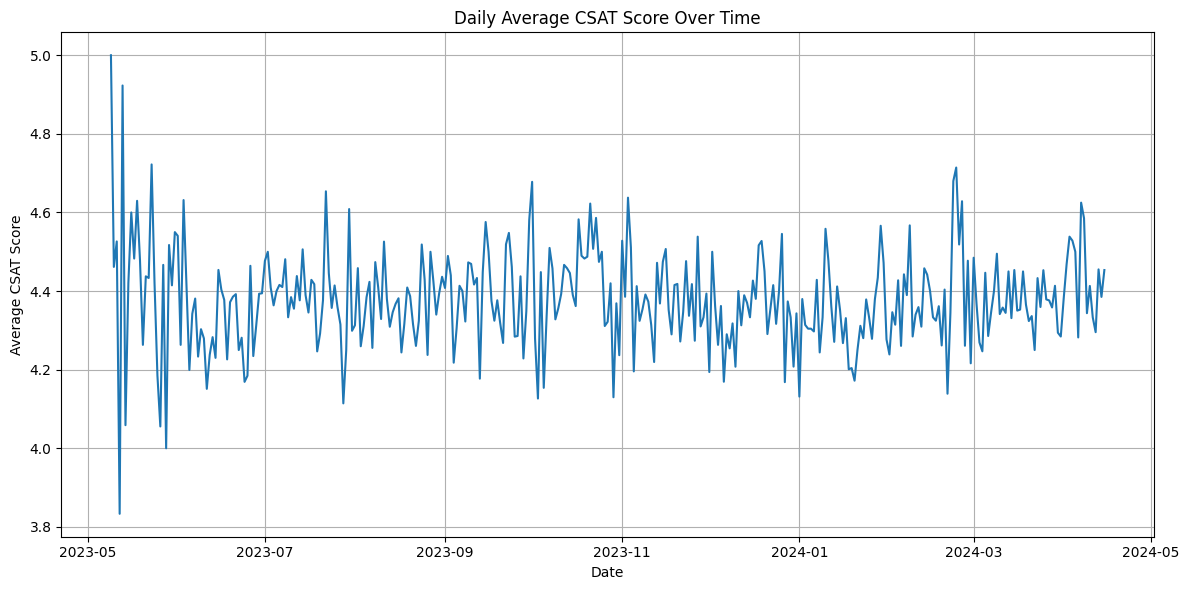

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_avg_csat.index, y=daily_avg_csat.values)
plt.title('Daily Average CSAT Score Over Time')
plt.xlabel('Date')
plt.ylabel('Average CSAT Score')
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the average CSAT scores by content platform, I will create a bar plot using `platform_avg_csat`, providing a clear comparison across different platforms.



<ipython-input-7-1cc904fcc779>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_avg_csat.index, y=platform_avg_csat.values, palette='viridis')


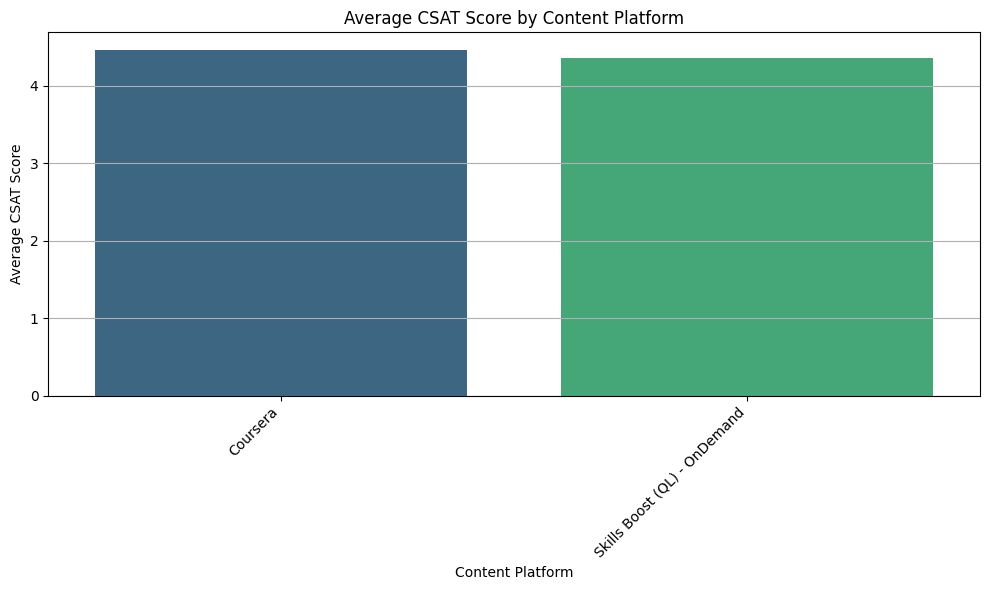

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=platform_avg_csat.index, y=platform_avg_csat.values, palette='viridis')
plt.title('Average CSAT Score by Content Platform')
plt.xlabel('Content Platform')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without explicitly assigning a `hue` variable. To address this, I will modify the `sns.barplot` call to assign the `x` variable to `hue` and set `legend=False`, as suggested by the warning, to ensure proper color mapping and suppress the legend, resulting in cleaner and more compliant code.



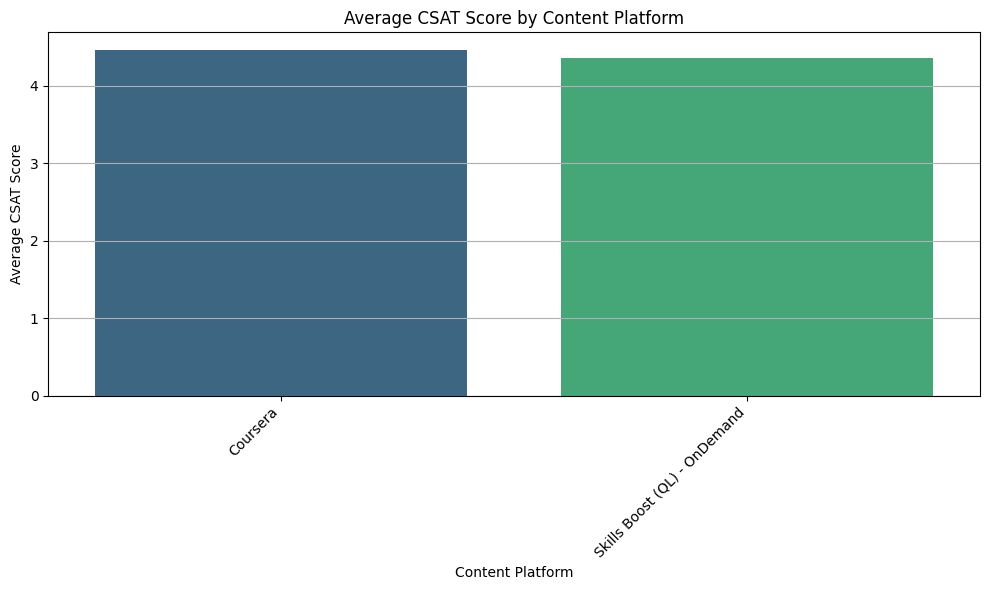

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=platform_avg_csat.index, y=platform_avg_csat.values, hue=platform_avg_csat.index, palette='viridis', legend=False)
plt.title('Average CSAT Score by Content Platform')
plt.xlabel('Content Platform')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the average CSAT scores by content owner, I will create a bar plot using `owner_avg_csat`, ensuring proper color mapping and suppressing the legend to avoid `FutureWarning`.



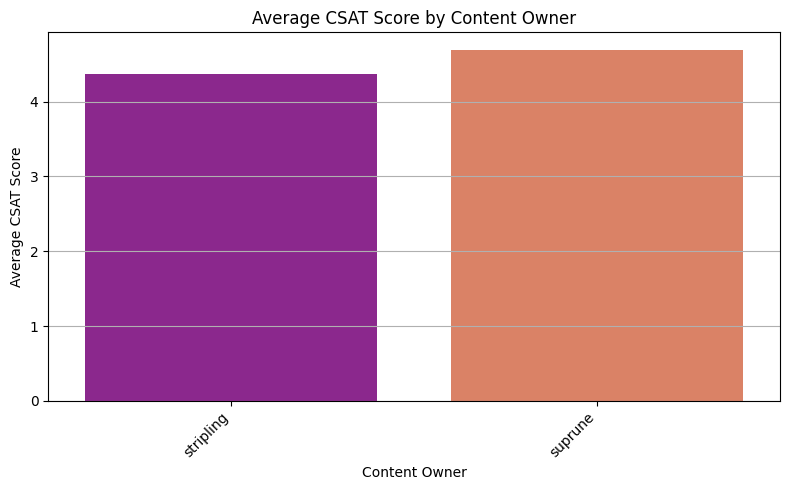

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=owner_avg_csat.index, y=owner_avg_csat.values, hue=owner_avg_csat.index, palette='plasma', legend=False)
plt.title('Average CSAT Score by Content Owner')
plt.xlabel('Content Owner')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the average CSAT scores by content language, I will create a bar plot using `language_avg_csat`, ensuring proper color mapping and suppressing the legend to avoid `FutureWarning`.



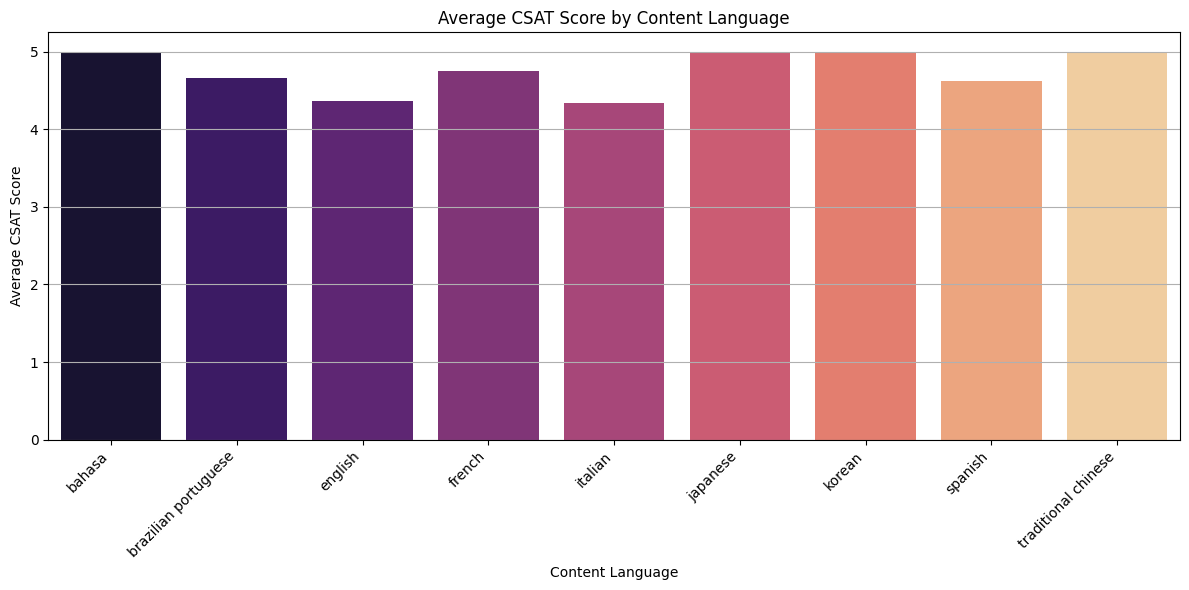

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=language_avg_csat.index, y=language_avg_csat.values, hue=language_avg_csat.index, palette='magma', legend=False)
plt.title('Average CSAT Score by Content Language')
plt.xlabel('Content Language')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Detect Anomalies

### Subtask:
Implement a method to detect anomalies within the dataset, focusing on the daily average CSAT scores.


**Reasoning**:
To detect anomalies in the daily average CSAT scores, I will calculate the first and third quartiles, determine the Interquartile Range (IQR), and then use these to establish upper and lower bounds for anomaly detection. Finally, I will filter the data to identify and print the anomalies.



In [ ]:
Q1 = daily_avg_csat.quantile(0.25)
Q3 = daily_avg_csat.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

anomalies = daily_avg_csat[(daily_avg_csat < lower_bound) | (daily_avg_csat > upper_bound)]

print("Identified Anomalies in Daily Average CSAT Scores:")
print(anomalies)

Identified Anomalies in Daily Average CSAT Scores:
Feedback Feedback Date Date
2023-05-09    5.000000
2023-05-12    3.833333
2023-05-13    4.923077
2023-05-14    4.058824
2023-05-23    4.722222
2023-05-26    4.055556
2023-05-28    4.000000
2023-10-01    4.677966
2024-02-23    4.680000
2024-02-24    4.714286
Name: Feedback Csat, dtype: float64


## Visualize Trends and Anomalies

### Subtask:
Generate visualizations, such as line plots for trends over time and scatter plots with anomaly highlighting, to clearly represent the identified trends and anomalies. Ensure legends are provided for clarity.


**Reasoning**:
To visualize the daily average CSAT score trends and highlight the identified anomalies, I will create a line plot for the daily average and overlay a scatter plot for the anomalies with distinct styling, adding a legend, title, and axis labels for clarity.



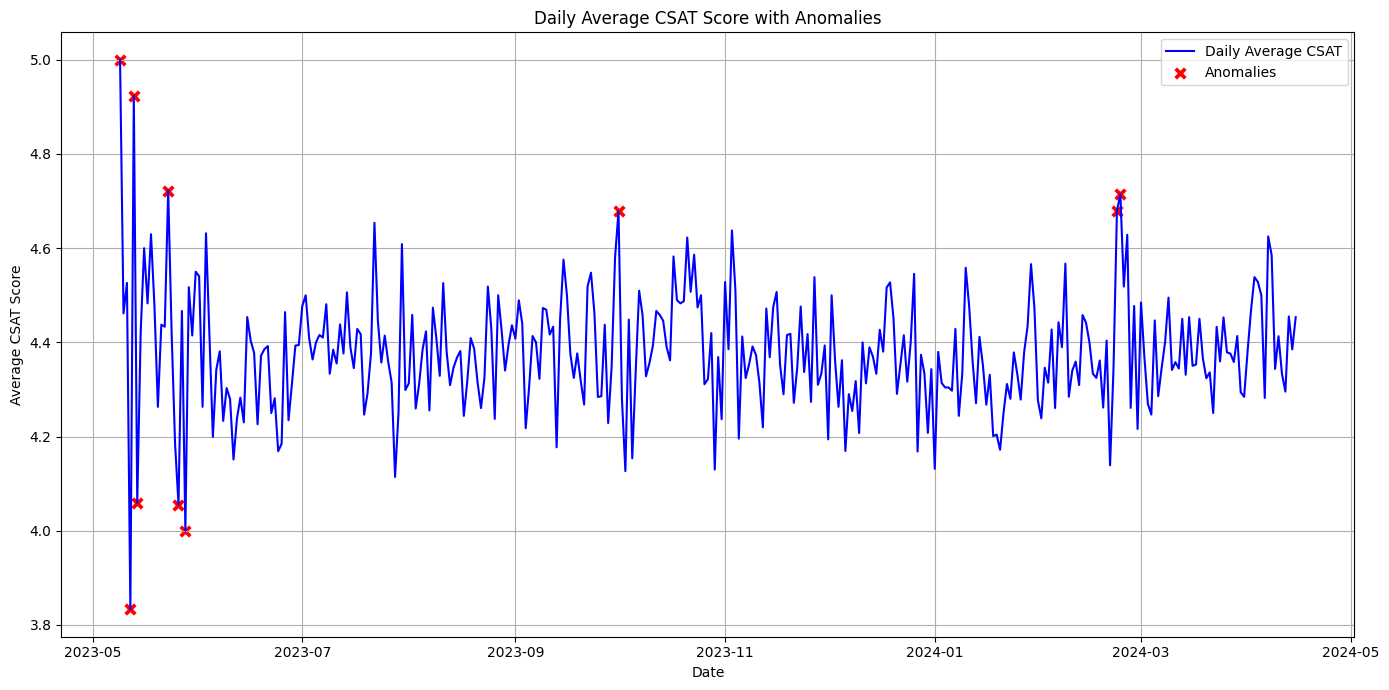

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_avg_csat.index, y=daily_avg_csat.values, label='Daily Average CSAT', color='blue')
sns.scatterplot(x=anomalies.index, y=anomalies.values, color='red', marker='X', s=100, label='Anomalies')
plt.title('Daily Average CSAT Score with Anomalies')
plt.xlabel('Date')
plt.ylabel('Average CSAT Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the identified trends and anomalies, and provide insights into their potential causes or implications.


## Summary:

### Data Analysis Key Findings

*   **Data Overview & Quality:** The dataset contains 30,000 entries across 13 columns. The 'Feedback Feedback Date Date' column was initially an object type and required conversion to datetime for temporal analysis.
*   **Missing Values:** The 'Feedback Csat Materials' column was 100% missing and subsequently dropped. High missingness was observed in free-text fields ('Feedback Csat Open Feedback' with ~69.51% and 'Feedback Csat Explanation' with ~54.71%). Moderate missing values were present in specific CSAT rating columns, ranging from ~16.06% to ~24.68%. Missing CSAT values were imputed using the median.
*   **Constant Columns:** 'Content Content Name' and 'Content Content Code' each contained only one unique value, indicating they might not be useful for differentiation within this dataset.
*   **CSAT Trends Over Time:** The daily average CSAT scores showed fluctuations, ranging from 3.83 to 5.00, indicating variability in user satisfaction on a day-to-day basis.
*   **CSAT by Content Platform:** Coursera received a slightly higher average CSAT of 4.467 compared to Skills Boost (QL) - OnDemand, which had an average CSAT of 4.361.
*   **CSAT by Content Owner:** Content owned by 'suprune' exhibited a considerably higher average CSAT of 4.692 compared to 'stripling' at 4.366.
*   **CSAT by Content Language:** Several languages (Bahasa, Japanese, Korean, Traditional Chinese) showed a perfect 5.0 average CSAT. English content had an average of 4.366, while other languages like Brazilian Portuguese (4.666), French (4.750), Italian (4.333), and Spanish (4.625) fell in between.
*   **Anomalies in Daily CSAT:** Using the Interquartile Range (IQR) method, 10 dates were identified as anomalies in daily average CSAT scores, including particularly high scores (e.g., 5.0 on 2023-05-09, 4.92 on 2023-05-13) and lower scores (e.g., 3.83 on 2023-05-12, 4.00 on 2023-05-28).

### Insights or Next Steps

*   **Investigate Performance Discrepancies:** Further analysis should focus on understanding why content owned by 'suprune' consistently achieves higher CSAT scores than 'stripling' and what factors contribute to the perfect 5.0 CSAT ratings for certain languages.
*   **Deep Dive into Anomalies:** Analyze the specific content, platform, and feedback received on dates identified as anomalies (both high and low CSAT) to understand the root causes of these significant deviations. This could involve examining the free-text feedback for those days.


# Task
## Analyze Negative Feedback

### Subtask:
Filter the DataFrame `df` to include only feedback with a 'Feedback Csat' score of 2 or less, which will represent negative feedback.

## Filter for Negative Feedback

### Subtask:
Filter the DataFrame `df` to include only feedback with a 'Feedback Csat' score of 2 or less, which will represent negative feedback.


**Reasoning**:
To filter for negative feedback, I will create a new DataFrame by selecting rows from the original DataFrame where the 'Feedback Csat' score is less than or equal to 2, and then display the first few rows of this new DataFrame to confirm the filtering.



In [ ]:
negative_feedback_df = df[df['Feedback Csat'] <= 2]
print("First 5 rows of Negative Feedback DataFrame:")
print(negative_feedback_df.head())

First 5 rows of Negative Feedback DataFrame:
   Feedback Feedback Date Date      Content Content Platform  \
3                   2023-05-10  Skills Boost (QL) - OnDemand   
5                   2023-05-10  Skills Boost (QL) - OnDemand   
28                  2023-05-11  Skills Boost (QL) - OnDemand   
36                  2023-05-12  Skills Boost (QL) - OnDemand   
45                  2023-05-12  Skills Boost (QL) - OnDemand   

   Content Content Owner           Content Content Name  Feedback Csat  \
3              stripling  Introduction to Generative AI            2.0   
5              stripling  Introduction to Generative AI            2.0   
28             stripling  Introduction to Generative AI            2.0   
36             stripling  Introduction to Generative AI            2.0   
45             stripling  Introduction to Generative AI            1.0   

                            Feedback Csat Explanation  \
3   Several answers in the assessment were misspel...   
5   The que

## Explore Negative Feedback Explanations

### Subtask:
Examine the 'Feedback Csat Explanation' and 'Feedback Csat Open Feedback' columns for the filtered negative feedback. This will involve looking at non-null values and potentially identifying common keywords or phrases.


**Reasoning**:
To understand the volume of textual feedback available, I will check the number of non-null entries in the 'Feedback Csat Explanation' and 'Feedback Csat Open Feedback' columns within the `negative_feedback_df`.



In [ ]:
print("Non-null entries in Feedback Csat Explanation (Negative Feedback):")
print(negative_feedback_df['Feedback Csat Explanation'].notnull().sum())

print("\nNon-null entries in Feedback Csat Open Feedback (Negative Feedback):")
print(negative_feedback_df['Feedback Csat Open Feedback'].notnull().sum())

Non-null entries in Feedback Csat Explanation (Negative Feedback):
768

Non-null entries in Feedback Csat Open Feedback (Negative Feedback):
447


**Reasoning**:
To understand the nature of the textual feedback, I will display a few random samples from the non-null entries in both 'Feedback Csat Explanation' and 'Feedback Csat Open Feedback' columns of the `negative_feedback_df`.



In [ ]:
print("\nRandom Samples from 'Feedback Csat Explanation' (Negative Feedback):")
print(negative_feedback_df['Feedback Csat Explanation'].dropna().sample(5, random_state=42).tolist())

print("\nRandom Samples from 'Feedback Csat Open Feedback' (Negative Feedback):")
print(negative_feedback_df['Feedback Csat Open Feedback'].dropna().sample(5, random_state=42).tolist())


Random Samples from 'Feedback Csat Explanation' (Negative Feedback):
['Tems are not too common for some people', 'Well structured content', 'no', 'Good', 'crisp introduction']

Random Samples from 'Feedback Csat Open Feedback' (Negative Feedback):
["why can't i get my certificate?", 'good course', 'thanks', 'El video es muy largo y hay muchos enlaces que repiten lo mismo. Quizá sería mejor en bloques más cortos y sintetizados.', 'Thank you Google...']


### Initial Observations on Negative Feedback:

Based on the random samples from 'Feedback Csat Explanation' and 'Feedback Csat Open Feedback' for negative CSAT scores, several themes emerge:

*   **Mixed Sentiment:** Even within negative CSAT scores, some feedback snippets are neutral or even positive (e.g., 'Well structured content', 'Good', 'crisp introduction', 'good course', 'Thank you Google...'). This suggests that a low CSAT score might not always be accompanied by explicitly negative textual feedback, or the specific feedback refers to a particular aspect, while the overall experience was poor.
*   **Assessment/Content Issues:** Some explanations point to specific problems like 'Tems are not too common for some people' or 'Several answers in the assessment were misspelled...', indicating issues with the content's clarity, accuracy, or suitability for the audience.
*   **Technical/Accessibility Issues:** A sample mentions "why can't i get my certificate?", which points to potential technical issues or problems with the learning platform's functionality.
*   **Pacing/Format:** One Spanish feedback mentions 'El video es muy largo y hay muchos enlaces que repiten lo mismo. Quizá sería mejor en bloques más cortos y sintetizados.' (The video is very long and there are many links that repeat the same thing. Perhaps it would be better in shorter, more synthesized blocks.), suggesting issues with content delivery format and length.
*   **Voice-over/Robotic Sound:** A previous sample (from the head of `negative_feedback_df` output) mentioned 'The voice over was very robotic', indicating an issue with lecture quality.

Overall, the feedback is diverse but points towards specific areas for improvement, including content quality, assessment accuracy, technical aspects of the platform, and content presentation.

## Summarize Negative Feedback

### Subtask:
Summarize the key themes and common issues identified from the negative feedback, providing insights into potential areas for improvement.


## Summarize Negative Feedback

### Subtask:
Summarize the key themes and common issues identified from the negative feedback, providing insights into potential areas for improvement.


**Reasoning**:
To identify key themes and common issues, I will combine the text from 'Feedback Csat Explanation' and 'Feedback Csat Open Feedback' columns within the negative feedback DataFrame. This will allow for a comprehensive analysis of all available textual feedback.



In [ ]:
negative_feedback_df['combined_feedback_text'] = negative_feedback_df['Feedback Csat Explanation'].fillna('') + ' ' + negative_feedback_df['Feedback Csat Open Feedback'].fillna('')
negative_feedback_df['combined_feedback_text'] = negative_feedback_df['combined_feedback_text'].str.strip().replace(r'\s+', ' ', regex=True)

print("First 5 rows of Negative Feedback DataFrame with combined text:")
print(negative_feedback_df[['Feedback Csat', 'combined_feedback_text']].head())